# Activist-13D — a quantitative teardown 🔬
### Pop vs drift split · excess-of-SPY drift at 1/3/6m · a Welch *t* + same-target placebo null · costs · lag & mega-cap robustness · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things the "13D pops and drifts" claim fuses: an **uncapturable announcement pop** (day-0 news) from the **tradable post-announcement drift** (buy +1 day, hold H months, in **excess of SPY**). And we confront the drift with the **sample size**: across ~25 outcome-selected events the excess is positive but its standard error swamps it.

> ⚠️ **Data + selection note.** A clean full-coverage 13D panel isn't free; we use a **hardcoded basket of 25 famous campaigns** — selected on outcome, a bias that runs *toward* the claim (named on the Signal axis). Real data: yfinance daily adjusted closes, 25 targets + SPY, 2010→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from activist_13d import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, TBL = data.load_real()
else:
    PRICES, TBL = None, None
print("real event-price cache present:", HAVE_REAL,
      "| activist campaigns priced:", (0 if TBL is None else len(TBL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-04', 'end': '2026-06-18', 'days': 4140, 'years': 16.5, 'n_events': 25, 'pop': (24, 1.22, 0.62, 62, 0.99), 'h1': (1, 25, 1.74, 1.36, 64, 1.11, 0.183), 'h3': (3, 25, 0.89, 1.53, 56, 0.4, 0.449), 'h6': (6, 25, 3.78, 3.16, 60, 0.98, 0.283), 'net': [(1, 1.74, 1.64), (3, 0.89, 0.79), (6, 3.78, 3.68)], 'lag': [(0, 3.88, 1.09, 0.277), (1, 3.78, 0.98, 0.283), (2, 5.33, 1.13, 0.195), (5, 4.78, 1.03, 0.223)], 'nomega': (22, 2.49, 0.6, 0.37), 'syn': [(0.0, 25, 3.64, 52, 0.72, 0.262), (0.2, 25, 27.8, 80, 4.45, 0.0)]}


real event-price cache present: True | activist campaigns priced: 25


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | 6-month excess drift **+3.8%** vs SPY, Welch **t = 0.98** (best across horizons is 1m **t = 1.11**), placebo **p = 0.18**; non-monotone (3m **+0.9%**), and dropping 3 mega-caps drops *t* to **0.60**. Positive but **fails t ≥ 2**. |
| **Tradability** | `FRAGILE` | **25 rare events**; net of 10-bps costs the per-trade number is intact (**3.7%** at 6m) — **significance & frequency**, not cost, kill it. |
| **Free lunch?** | `BUSTED` | A same-target placebo says random dates match the 13D basket **~28%** of the time. The 'free ride' is **selection** — you remember the Icahn/Elliott wins. |

> 💡 In plain words: the announcement *pop* is real news you can't buy; the post-filing *drift* you can buy is a positive whisper that ~25 outcome-selected events can't certify and that a few mega-caps carry.

## 1 · The claim, steelmanned

Let $P_t$ be the target close and $M_t$ SPY. For event $j$ with announcement day $0_j$, define the **pop** $\pi_j = P_{0_j}/P_{0_j-1}-1$ (the news) and the **tradable drift** $x_j^{(H)} = \big(P_{0_j+1+H}/P_{0_j+1}-1\big) - \big(M_{0_j+1+H}/M_{0_j+1}-1\big)$ — buy one day after, hold $H$, in **excess of SPY**.

- **H₁ (the drift predicts).** $\mathbb{E}[x^{(H)}] > 0$ for $H\in\{1,3,6\}$m — a *positive excess over the market* you can actually buy.
- **H₂ (it's deployable).** The excess is large/frequent enough, net of costs, to allocate to.
- **H₃ (free ride).** The drift reflects the *13D timing*, not just owning special names (cheap, volatile, trending) that would have drifted on *any* entry date.

Steelman from the literature: Brav, Jiang, Partnoy & Thomas (2008) find a real **+7–8%** abnormal return *around* the filing on 1,000+ events. We find **H₁ not rejected but not supported** (positive, $t < 2$, non-monotone), **H₂ rejected** (~25 events, excess in the noise), **H₃ rejected** (the same-target placebo matches the basket ~1 in 4). The legend is true where it's unreachable (the pop) and unproven where it would pay (a *distinct* drift).

## 2 · So what? — what rides on each answer

The teardown is one decomposition: a mean excess drift against zero, judged by its **standard error**, on a sample chosen to *favour* the claim.

$$\widehat{x}^{(H)} = \frac1k\sum_j x_j^{(H)},\qquad t = \frac{\widehat{x}^{(H)}}{s_x/\sqrt{k}}.$$

With $k \approx 25$, $s_x/\sqrt{k}$ is large: a few-point $\widehat{x}$ drowns in its own SE. A raw **win-rate** is the wrong lens — these are volatile names in an up-drifting market, so >50% wins is the baseline, not the signal. And measuring excess against *zero* would credit plain beta, so we race **target vs SPY**. The honest small-sample instrument is a **same-target placebo**: resample each name's excess from a *random* entry date and ask how often chance matches the 13D timing. That number, not the point estimate, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Event set.** A **hardcoded** table of 25 famous activist 13D campaigns (yfinance adjusted closes, 2010-01-04→2026-06-18, 4,140 price days). Explicit **outcome-selected** basket — survivorship runs *for* the claim (named on the axis).
- **Pop (reported).** Day-0 return of the target — the news, not a trade.
- **Drift (tradable).** Enter the close **1 day after** the announcement (no look-ahead), hold $H\in\{1,3,6\}$m, return in **excess of SPY**; drop events whose horizon overruns the tape.
- **Null #1 (Welch t).** Mean excess vs zero.
- **Null #2 (same-target placebo).** 20,000 draws of one random-date excess **per name**; $p=\Pr[\text{random-date basket mean} \ge \text{13D basket mean}]$ — controls for the targets' own drift.
- **Costs.** 1-day lag + a 10-bps round-trip on the buy-and-hold trade.
- **Robustness.** Entry-lag sweep (0/1/2/5d) and a mega-cap drop.
- **Positive control.** A deterministic set of 25 synthetic events with a **known** planted drift: the engine must recover it **and** must NOT manufacture significance when the true drift is zero.

## 4 · The teardown

### 4a · Pop vs drift — the two objects, side by side

The announcement pop (day 0, *uncapturable*) next to the mean excess drift you can buy at 1 / 3 / 6 months, each with its $\pm$ standard error. The pop is real but tiny here; the drift is positive, small, and **non-monotone**.

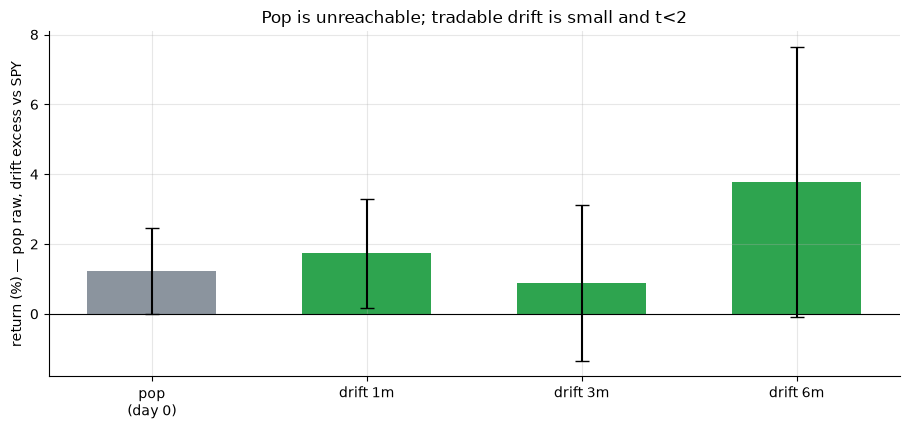

Welch t by horizon: {'1m': 1.11, '3m': 0.4, '6m': 0.98}


In [2]:
hs = [1, 3, 6]
if HAVE_REAL:
    pops = st.announcement_pops(PRICES, TBL); pop_m = pops.mean()*100
    pop_se = pops.std(ddof=1)/np.sqrt(len(pops))*100
    cm, ses, ts = [], [], []
    for m in hs:
        ex = st.event_excess_drift(PRICES, TBL, m)
        cm.append(ex.mean()*100); ses.append(ex.std(ddof=1)/np.sqrt(len(ex))*100)
        ts.append(st.welch_t_vs_zero(ex))
else:
    pop_m = R['pop'][1]; pop_se = 1.2
    cm = [R['h1'][2], R['h3'][2], R['h6'][2]]; ses = [1.6, 2.2, 3.9]
    ts = [R['h1'][5], R['h3'][5], R['h6'][5]]
labels = ['pop\n(day 0)'] + [f'drift {m}m' for m in hs]
vals = [pop_m] + cm; errs = [pop_se] + ses
cols = [GREY] + [GREEN]*3
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(range(len(vals)), vals, yerr=errs, capsize=5, color=cols, width=.6)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(range(len(vals))); ax.set_xticklabels(labels)
ax.set_ylabel('return (%) — pop raw, drift excess vs SPY')
ax.set_title('Pop is unreachable; tradable drift is small and t<2'); 
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: the day-0 pop is **+1.2%** (news, not yours); the tradable drift is **+1.7% / +0.9% / +3.8%** at 1/3/6m, with Welch *t* of **1.11 / 0.40 / 0.98** — all below 2, and the 3-month *dip* betrays a number wobbling inside its error bar. H₁ is **not rejected, not supported.**

### 4b · The decisive test — a same-target placebo null

For each name, draw its 6-month excess from a *random* entry date; do it 20,000 times. The histogram is the null for the basket mean — what you'd get buying the same stocks on random days. The 13D basket is the green line; the *p*-value is the right-tail mass.

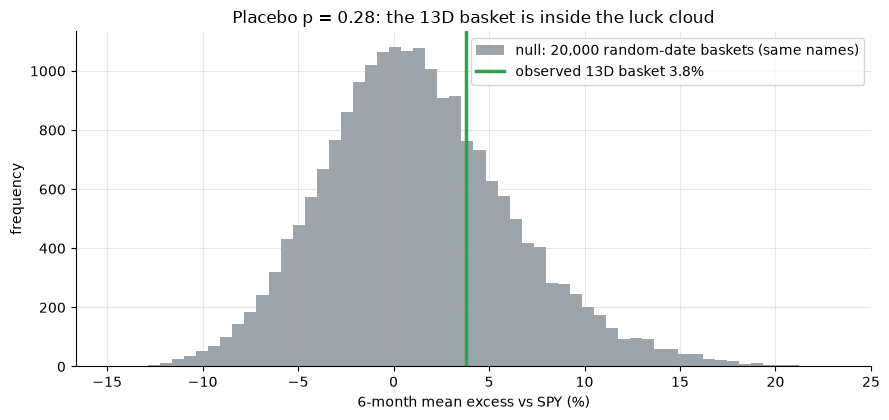

P[random-date basket >= 13D basket] = 0.283  (need <0.05 to call it real)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PRICES, TBL, 6, n_draws=20000); obs = pl['obs_mean']*100; pval = pl['p_value']
    spy = PRICES['SPY'].dropna(); h = st.TRADING_DAYS[6]; pools=[]
    for _, r in TBL.iterrows():
        s = PRICES[r['ticker']].dropna(); common = s.index.intersection(spy.index)
        sc = s.reindex(common).values; sp = spy.reindex(common).values
        if len(common) > h+2:
            pool = (sc[h:]/sc[:-h]-1) - (sp[h:]/sp[:-h]-1); pools.append(pool[np.isfinite(pool)])
    rng = np.random.default_rng(390)
    draws = np.array([np.mean([p[rng.integers(0,len(p))] for p in pools]) for _ in range(20000)])
else:
    obs = R['h6'][2]; pval = R['h6'][6]; rng = np.random.default_rng(390)
    draws = rng.normal(0.0, 0.045, 20000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=60, color=GREY, alpha=.85, label=f'null: {len(draws):,} random-date baskets (same names)')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed 13D basket {obs:.1f}%')
ax.set_xlabel('6-month mean excess vs SPY (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the 13D basket is inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[random-date basket >= 13D basket] = {pval:.3f}  (need <0.05 to call it real)')

> 💡 In plain words: **28%** of random-date baskets on the *same names* match or beat the 13D basket. A real timing edge would push the green line into the far right tail; instead it sits mid-cloud. **H₃ rejected** — the drift is owning special names, not the activist's calendar. This is selection wearing a strategy's clothes.

### 4c · Robustness — lag-flat, and a few names carry it

Shift the entry lag (0/1/2/5 days) and, separately, drop the three mega-cap targets (AAPL, MSFT, DIS). The *t* never approaches 2 at any lag (so it's not an execution artefact), and removing three names **halves the mean and pushes *t* to 0.60** — the fingerprint of a fragile, name-driven estimate.

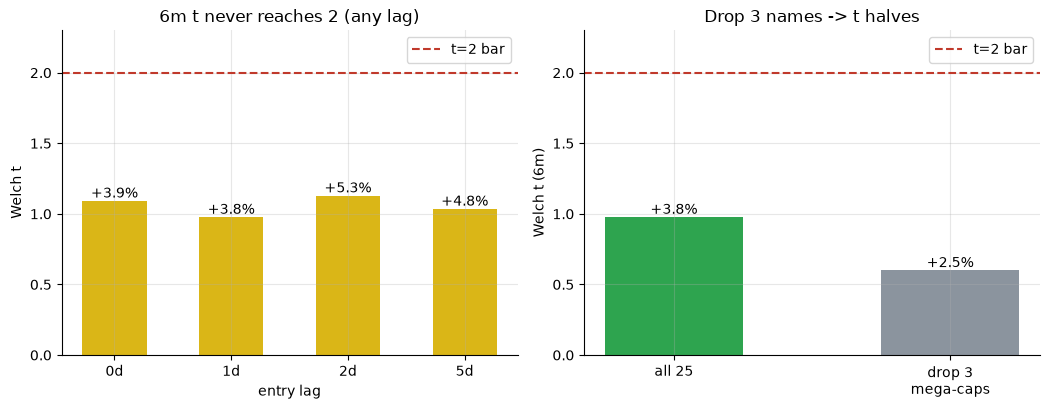

lag-6m t: [1.09, 0.98, 1.13, 1.03]  | full t=0.98 (+3.8%) vs no-mega t=0.60 (+2.5%)


In [4]:
if HAVE_REAL:
    lags = [0,1,2,5]
    lt = [st.summarize(PRICES, TBL, 6, lag=L)['t'] for L in lags]
    lm = [st.summarize(PRICES, TBL, 6, lag=L)['mean_excess']*100 for L in lags]
    sub = TBL[~TBL['ticker'].isin(['AAPL','MSFT','DIS'])].reset_index(drop=True)
    s_full = st.summarize(PRICES, TBL, 6); s_no = st.summarize(PRICES, sub, 6)
    full_t, no_t = s_full['t'], s_no['t']; full_m = s_full['mean_excess']*100; no_m = s_no['mean_excess']*100
else:
    lags = [l[0] for l in R['lag']]; lt = [l[2] for l in R['lag']]; lm = [l[1] for l in R['lag']]
    full_t, no_t = R['h6'][5], R['nomega'][2]; full_m = R['h6'][2]; no_m = R['nomega'][1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar([f'{L}d' for L in lags], lt, color=AMBER, width=.55)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,(t,m) in enumerate(zip(lt,lm)): a1.annotate(f'{m:+.1f}%',(i,t),ha='center',va='bottom')
a1.set_title('6m t never reaches 2 (any lag)'); a1.set_xlabel('entry lag'); a1.set_ylabel('Welch t'); a1.set_ylim(0,2.3); a1.legend()
a2.bar(['all 25','drop 3\nmega-caps'], [full_t, no_t], color=[GREEN, GREY], width=.5)
a2.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,(t,m) in enumerate(zip([full_t,no_t],[full_m,no_m])): a2.annotate(f'{m:+.1f}%',(i,t),ha='center',va='bottom')
a2.set_title('Drop 3 names -> t halves'); a2.set_ylabel('Welch t (6m)'); a2.set_ylim(0,2.3); a2.legend()
plt.tight_layout(); plt.show()
print(f'lag-6m t: {[round(x,2) for x in lt]}  | full t={full_t:.2f} ({full_m:+.1f}%) vs no-mega t={no_t:.2f} ({no_m:+.1f}%)')

> 💡 In plain words: the result is **flat in the entry lag** — buy same-day or a week later, the *t* stays near 1 — so this isn't a timing/execution artefact. But it is **fragile in the cross-section**: three mega-cap names carry most of the modest positive mean, exactly what you expect when the basket was selected on fame. There is no lag and no sub-basket where it clears t = 2.

### 4d · Faithful-engine & power control — we know the truth here

On 25 *synthetic* 13D events (each a GBM path sharing a market factor, a day-0 pop, and a **known** post-announcement drift): with **zero** planted drift the test must stay below t=2 (25 events can't fake significance); with a **+20%/6m** planted drift it must light up. Both hold — the engine is unbiased *and* this sample size only detects implausibly large edges.

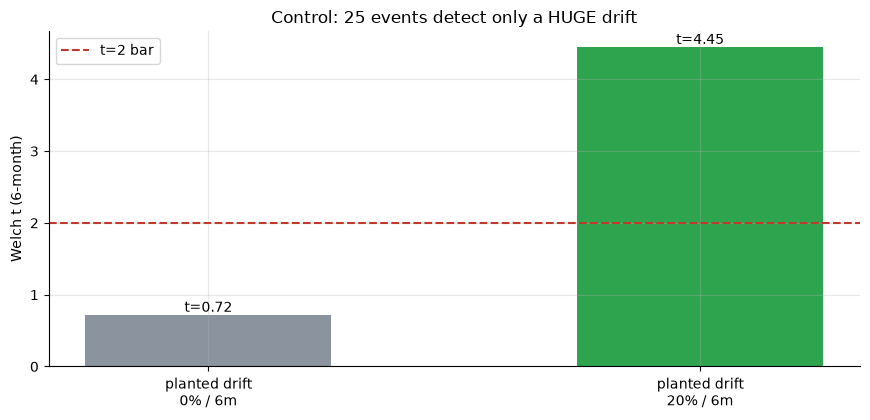

planted +0%/6m: n=25 mean=3.6% win=52% t=0.72 p=0.262
planted +20%/6m: n=25 mean=27.8% win=80% t=4.45 p=0.000


In [5]:
res = []
for edge in (0.0, 0.20):
    p, t = data.synthetic_events(n_events=25, drift_6m=edge, seed=390)
    s = st.summarize(p, t, 6)
    res.append((edge, s['n'], s['mean_excess']*100, s['win_rate']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted drift\n{e*100:.0f}% / 6m' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (6-month)'); ax.set_title('Control: 25 events detect only a HUGE drift'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,m,w,t,p in res: print(f'planted {e*100:+.0f}%/6m: n={k} mean={m:.1f}% win={w:.0f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** real drift the control sits at **t = 0.72** (below 2 — no false positive, even though noise tilted the mean to +3.6%); only a **+20%/6m** drift — enormous — reaches **t = 4.45**. So the machinery is honest, and the real-tape *t* of ~1 is exactly what an *absent or tiny* drift looks like through a 25-event keyhole. The sample size is the verdict.

## 5 · The verdict

- **Signal `WEAK`** — 6m excess **+3.8%** at Welch **t = 0.98** (best horizon 1m **t = 1.11**), placebo **p = 0.18**; non-monotone (3m **+0.9%**) and mega-cap-fragile (**t = 0.60** without AAPL/MSFT/DIS). Literature support + a positive-but-insignificant, fragile estimate on an outcome-selected basket ⇒ WEAK, not REAL (the t≥2 bar is not met).
- **Tradability `FRAGILE`** — **25 rare events**; net of 10-bps costs the per-trade number is intact (**3.7%** at 6m), so **significance & frequency**, not cost, make it un-allocatable. No NAV-scale edge.
- **Free lunch? `BUSTED`** — the same-target placebo says random dates match the 13D basket **~28%** of the time. A selection mirage — you remember the Icahn/Elliott wins and forget the duds.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* 6-month excess have to be for a $k$-event study to detect it at t=2? At $k=25$ you'd need an excess several times the one observed; the real drift lives far below the detection floor.

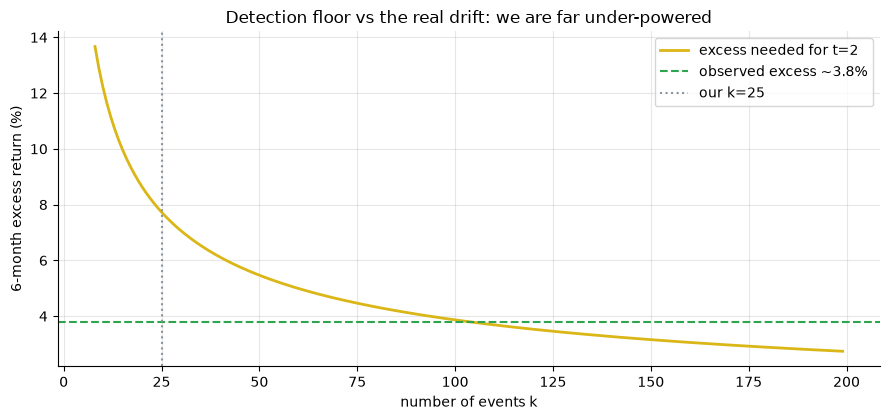

at k=25 you need ~7.7% excess for t=2; observed ~3.8% -> under-powered by ~2.0x


In [6]:
if HAVE_REAL:
    ex = st.event_excess_drift(PRICES, TBL, 6); sd = ex.std(ddof=1)
    obs_excess = R['h6'][2]/100
else:
    sd = 0.19; obs_excess = R['h6'][2]/100
ks = np.arange(8, 200)
min_detectable = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_detectable*100, c=AMBER, lw=2, label='excess needed for t=2')
ax.axhline(obs_excess*100, c=GREEN, ls='--', label=f'observed excess ~{obs_excess*100:.1f}%')
ax.axvline(R['n_events'], c=GREY, ls=':', label=f"our k={R['n_events']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('6-month excess return (%)')
ax.set_title('Detection floor vs the real drift: we are far under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_events'])
print(f'at k={R["n_events"]} you need ~{need*100:.1f}% excess for t=2; observed ~{obs_excess*100:.1f}% -> under-powered by ~{need/obs_excess:.1f}x')

> 💡 In plain words: the amber curve is the **minimum detectable excess**; the green line is what we actually see. They don't meet until $k$ is several times larger than a famous-13D basket will ever deliver. Even granting the lore a *real* few-point edge, you'd need on the order of a hundred clean filings to prove it — and the full EDGAR panel (with the forgotten duds) would only *dilute* the mean. There is no sizing, threshold or cost assumption that manufactures statistical power from 25 outcome-selected events — **the fame that makes the trade romantic is exactly what makes it untestable and untradable.**

## 7 · Going further

- **The literature's real result.** Brav, Jiang, Partnoy & Thomas (2008) document a genuine **+7–8%** abnormal return around the filing on 1,000+ events — but concentrated in the uncapturable announcement window, with the post-filing alpha localised in targets that are later **acquired** (Greenwood & Schor, 2009). The outside-buyer drift is the thin tail of that distribution.
- **Full-panel replication.** Build the complete EDGAR 13D panel (genuine first-disclosure dates, ticker-mapped), buy one day after each, race vs SPY; the survivorship tilt that *helps* our basket vanishes and the drift should weaken.
- **Condition on outcome / activist.** Split by eventual sale vs fizzle, and by activist track record; the edge, if any, is a conditional one, not a blanket 'buy every 13D.'

*The reproducible core is offline and deterministic; the event set is an explicit outcome-selected basket. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*